<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">Signal and noise correlations in an unfamiliar dataset</h3>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

This morning you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel,
along with the dataset it came from &mdash; ideally one you did *not* work on this morning. You are
going to reproduce it, then use that dataset to ask a new question.

<h3>What you will do</h3>

| Part | Task |
| --- | --- |
| 1 | Load the dataset and work out what is in it |
| 2 | Reproduce your classmate's figure, and test the claim in its caption |
| 3 | Build a raster and a PSTH &mdash; aggregating across trials |
| 4 | Learn what a correlation coefficient actually computes |
| 5 | Compute signal and noise correlations |
| 6 | Check whether your result is trustworthy |
| 7 | Decide which questions this dataset can and cannot answer |

<h3>What you will hand in</h3>

A short README documenting: which figure and dataset you chose, what you found in the data, the
decisions you made at each analysis step and why, and an honest assessment of what your final
numbers do and do not support.

<h3>Important</h3>

This notebook works through **one example dataset** to show you what the process looks like. It is
not a template to copy. Your dataset will have different containers, different column names, and
different answers. **The process transfers; the code does not.**

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

You can now generate an analysis faster than you can check one. Ask an LLM for a correlation
matrix and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

So the questions to keep asking are:

- **What is actually in this file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?**
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the data and find out what is in it</h1>

</div>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

data_dir = '/data'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Start with the metadata table</h3>

Each project has a metadata CSV in */data/metadata* with one row per session. Read this before
opening any NWB file &mdash; it tells you how many sessions exist, which subjects, and what was
recorded, far faster than opening files one at a time.

</div>

In [2]:
# EDIT: your project's metadata file
metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'ophys_mFISH_metadata.csv'))
metadata.head()

,subject_id,session_date,genotype,modality,session_type
0,790322,2025-06-26,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93,multiplane-ophys,OPHYS_images


In [3]:
# What is in this dataset?
print('sessions:', len(metadata))
print('subjects:', metadata.subject_id.nunique())
print('genotypes:', metadata.genotype.unique())

sessions: 1
subjects: 1
genotypes: <StringArray>
['Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93']
Length: 1, dtype: str


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What can you learn about your dataset from the metadata alone? How many
sessions per subject? What session types? Are there columns whose meaning you cannot guess?

Record what you find, and what you had to look up, in your README.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Open one session</h3>

All SWDB data is in NWB format with a Zarr backend. `pynwb.read_nwb` opens either backend.

</div>

In [4]:
# EDIT: build the path to one session's NWB file for your dataset
subject_id = metadata.subject_id.unique()[0]
session_dir = os.path.join(data_dir, f'{subject_id}_ophys_mFISH')
sessions = sorted(os.listdir(session_dir))
session = sessions[0]

nwb_file = [f for f in os.listdir(os.path.join(session_dir, session)) if f.endswith('.nwb.zarr')][0]
nwb_path = os.path.join(session_dir, session, nwb_file)
nwb_path

'data/pophys.nwb.zarr'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFC067; ">

I don't think this read_nwb_file function is necessary. If pynwb.read_nwb fails then it will throw an error already. 

In [5]:
def read_nwb_file(path):
    """Open an NWB file, falling back to hdmf-zarr if pynwb cannot construct it.

    Datasets that use custom NWB extensions can fail to open if the matching
    extension package is missing OR if an installed version conflicts with the
    version cached inside the file. Both raise a ConstructError. The Zarr store
    can still be read directly in that case (see below).
    """
    return pynwb.read_nwb(path)


try:
    nwb = read_nwb_file(nwb_path)
    print('opened with pynwb:', type(nwb).__name__)
except Exception as error:
    print('pynwb could not construct this file:', type(error).__name__)
    print('see the note below on NWB extensions')
    raise

opened with pynwb: NdxEventsNWBFile


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFC067; ">

I'm confused why this dataset doesn't have anything in intervals or acquisition? 

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What containers does this file have?</h3>

Three containers hold almost everything you need. Their contents differ by dataset, so look before
you index.

| container | usually holds |
| --- | --- |
| `nwb.processing` | processed neural activity, and often behavior |
| `nwb.intervals` | epoch and stimulus tables, trials |
| `nwb.acquisition` | raw acquired signals |

</div>

In [6]:
print('processing:', list(nwb.processing.keys()))
print('intervals: ', list(nwb.intervals.keys()))
print('acquisition:', list(nwb.acquisition.keys()))

processing: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
intervals:  []
acquisition: []


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFC067; ">

I'm confused what's happening here - maybe if I could access the data folders it would make more sense. Is this something that would be obvious when looking at the /data folder? I'm not familiar with ndx-events or ndx-change-detection-task 

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In our example session the neural data and the behavior data are in **two separate NWB
files** that share a session name and a clock &mdash; so we open both. Most datasets are one file.
This is the sort of dataset-specific quirk you find by looking, and should write in your README.

<b>A second quirk, worth naming because it will happen to you:</b> both of these files declare
custom NWB <b>extensions</b>, and `pynwb.read_nwb` raises a `ConstructError` when it cannot build
the types they define. We hit this twice, for two different reasons:

- The <b>behavior</b> file needs `ndx-change-detection-task`, which is installed on the capsule but
  is not on PyPI &mdash; so off-capsule it simply cannot be constructed.
- The <b>ophys</b> file needs `ndx-events`. Counterintuitively, it opens fine when that package is
  <i>not</i> installed (pynwb then reads the spec cached inside the file), and <b>fails</b> when a
  conflicting version of `ndx-events` <i>is</i> installed and imported.

So "does this file open" can depend on what else is in your environment. If you hit a
`ConstructError`, read the message: it names the type it could not build, which points at the
extension involved. Nothing is wrong with the data.

The cell below falls back to reading the Zarr store directly, which bypasses the extension
machinery entirely. That is a useful escape hatch, but note the tradeoff &mdash; you get raw arrays
and tables without any of the convenience the NWB object model provides.

</div>

In [7]:
# --- EXAMPLE-DATASET SPECIFIC: this dataset splits neural and behavior into two files ---
behavior_path = nwb_path.replace('pophys', 'behavior')

try:
    nwb_behavior = pynwb.read_nwb(behavior_path)
    stim = nwb_behavior.intervals['stimulus_presentations'].to_dataframe()
    trials = nwb_behavior.intervals['trials'].to_dataframe()
except Exception as error:
    # fallback: read the Zarr store directly when a custom extension is unavailable
    print('pynwb could not open the behavior file:', type(error).__name__)
    print('falling back to reading the Zarr store directly\n')
    import zarr

    def zarr_table(group):
        """Read an NWB table out of a Zarr store as a DataFrame."""
        columns = {}
        for key in group.array_keys():
            if key.endswith('_index'):
                continue
            array = group[key]
            if array.ndim != 1:
                continue
            values = array[:]
            if values.dtype.kind in 'OS':
                values = np.array([v.decode() if isinstance(v, bytes) else v for v in values])
            columns[key] = values
        n = max(len(v) for v in columns.values())
        return pd.DataFrame({k: v for k, v in columns.items() if len(v) == n})

    zb = zarr.open(behavior_path, mode='r')
    stim = zarr_table(zb['intervals/stimulus_presentations'])
    trials = zarr_table(zb['intervals/trials'])
    running_speed = zb['processing/running/speed/data'][:]
    running_ts = zb['processing/running/speed/timestamps'][:]

print('stimulus presentations:', stim.shape)
print('trials:', trials.shape)

pynwb could not open the behavior file: ConstructError
falling back to reading the Zarr store directly

stimulus presentations: (4799, 14)
trials: (774, 28)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Pull out the neural activity</h3>

This dataset has 8 imaging planes. We start with one plane, exactly as in this morning's
tutorial.

</div>

In [8]:
# EDIT: the path to dF/F in your dataset
plane = 'VISp_0'
dff_series = nwb.processing[plane]['dff_timeseries']['dff_timeseries']

dff = dff_series.data[:]
ts = dff_series.timestamps[:]

print('dff shape (nframes, nrois):', dff.shape)
print('timestamps shape:', ts.shape)

dff shape (nframes, nrois): (39130, 67)
timestamps shape: (39130,)


In [9]:
frame_rate = 1 / np.median(np.diff(ts))

print(f'frame rate: {frame_rate:.2f} Hz')
print(f'session duration: {ts[-1] / 60:.1f} min')

frame rate: 10.74 Hz
session duration: 61.1 min


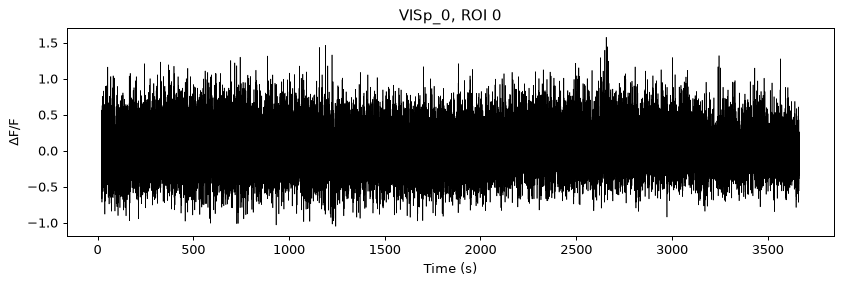

In [10]:
# Sanity check: plot one ROI's trace
ROI = 0

plt.figure(figsize=(11, 3))
plt.plot(ts, dff[:, ROI], 'k', lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel(r'$\Delta$F/F')
plt.title(f'{plane}, ROI {ROI}')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The variables the rest of the notebook uses</h3>

Everything from here on uses the handful of variables below. **This is the cell you edit to run
this notebook on a different dataset** &mdash; find the equivalent pieces in your NWB file and
assign them here. Nothing after this cell refers to a dataset by name.

If your dataset stores spike times rather than a continuous signal, see the note in Part 3 on
binning them.

</div>

In [11]:
# =====================================================================
# FILL IN FOR YOUR DATASET
# =====================================================================
activity = dff              # (n_timepoints, n_cells)
timestamps = ts             # (n_timepoints,) in seconds
events = stim               # one row per stimulus presentation / trial

CONDITION_COLUMN = 'image_name'   # which column labels the stimulus condition
ONSET_COLUMN = 'start_time'       # which column gives the event time
# =====================================================================

print('activity: ', activity.shape)
print('events:   ', events.shape)
print('condition column:', CONDITION_COLUMN)

activity:  (39130, 67)
events:    (4799, 14)
condition column: image_name


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Print the columns of your event table. Which describe *what was presented*,
which describe *what the animal did*, and which are identifiers or bookkeeping?

Any column you cannot classify is one to look up in the databook.

</div>

In [12]:
print(list(events.columns))
events.head()

['HED', 'epoch_name', 'id', 'image_name', 'is_change', 'lick_latency', 'omitted', 'orientation', 'start_frame', 'start_time', 'stimulus_presentations_id', 'stop_frame', 'stop_time', 'trials_id']


,HED,epoch_name,id,image_name,is_change,lick_latency,omitted,orientation,start_frame,start_time,stimulus_presentations_id,stop_frame,stop_time,trials_id
0,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,0,im065,False,0.445934,False,NaN,1199,41.563006,0,1214,41.813176,0
1,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,1,im065,False,NaN,False,NaN,1244,42.313616,1,1259,42.563806,0
2,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,2,im065,False,NaN,False,NaN,1289,43.064226,2,1304,43.314446,1
3,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,3,im065,False,0.662764,False,NaN,1334,43.814836,3,1349,44.065056,1
4,"Sensory-event, Visual-presentation, (Image, Label/im065)",change_detection,4,im065,False,0.062234,False,NaN,1379,44.565486,4,1394,44.815676,1


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

For our example: `image_name` and `orientation` describe the stimulus; `is_change` and
`omitted` describe its role in the task; `lick_latency` describes behavior; `trials_id` links to
the trials table; `HED` is a semantic annotation string.

The one worth pausing on is `is_change`. In this task most presentations repeat the previous image
and a few are changes the animal must report. Those are **not the same kind of event**, and that
distinction will matter when we choose which events to analyze.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What is *missing* from this dataset that you might have assumed was there?

Check specifically for: running speed, pupil, licks, rewards, cell-type labels, and any
quality-control flags on the cells. For each, either find it or record that it is absent.

</div>

In [13]:
# Where is behavior stored in this file?
for container_name, container in [('processing', nwb.processing)]:
    for key in container.keys():
        print(container_name, '->', key)

processing -> VISp_0
processing -> VISp_1
processing -> VISp_2
processing -> VISp_3
processing -> VISp_4
processing -> VISp_5
processing -> VISp_6
processing -> VISp_7


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our example has running speed but no pupil in the behavior file, and licks and rewards
are not stored as their own timeseries &mdash; they live in the trials table (`reward_time`) and in
a separate `events` table with an `event_type` column.

That last point cost us two wrong conclusions before we found the data. We first looked for a
`licks` container, found nothing, and concluded there were no licks. There are 2511 of them.

**When something appears to be absent, treat that as a hypothesis, not a result.** Look in every
container the file has before concluding it is missing.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce your classmate's figure</h1>

Here is the figure you picked, as it was posted:

> **Session overview.** Running speed and population-average activity across the whole session,
> with stimulus epochs shaded. *"The mouse runs in bouts throughout the session, and population
> activity is higher during the stimulus block than during the gray-screen periods."*

You have the caption and the claim. You do not have the code.

Reproducing it is a **mapping problem**: the caption names four things &mdash; running speed,
population activity, epochs, and a comparison between blocks &mdash; and you have to find each one
in your file. Some of them may not exist in your dataset. That is a finding, not a failure.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the population average: the mean activity across all cells at each
timepoint. What shape should it be before you write the line?

</div>

In [14]:
population = activity.mean(axis=1)

print('activity:  ', activity.shape, '(timepoints, cells)')
print('population:', population.shape, '(timepoints,)')

activity:   (39130, 67) (timepoints, cells)
population: (39130,) (timepoints,)


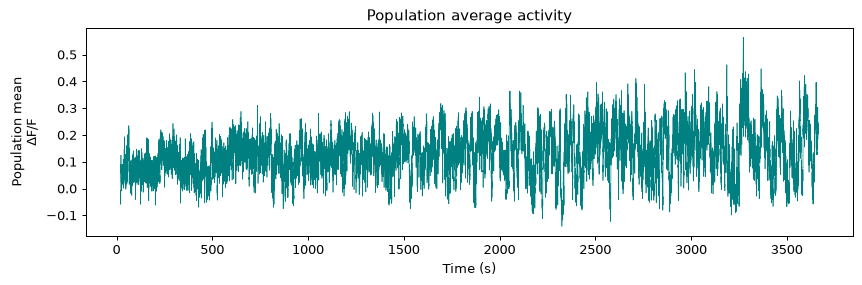

In [15]:
plt.figure(figsize=(11, 3))
plt.plot(timestamps, population, 'teal', lw=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Population mean\n' + r'$\Delta$F/F')
plt.title('Population average activity')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the epochs</h3>

Epochs divide the session into parts. Different datasets name this column differently
(`stim_name`, `epoch_name`, `stimulus_block_name`), so look at your event table's columns.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Where the epochs live varies by dataset. Some put an `epoch_name` column on the stimulus
table; others have a dedicated epochs table in `nwb.intervals`. **Look before you index** &mdash;
if you group the stimulus table by an epoch column that only ever takes one value, you will get a
single epoch spanning the session and never notice.

</div>

In [16]:
# What does the stimulus table say about epochs?
if 'epoch_name' in events.columns:
    print('epoch_name values in the stimulus table:')
    print(events.epoch_name.value_counts().to_string())

epoch_name values in the stimulus table:
epoch_name
change_detection    4799


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our stimulus table has an `epoch_name` column, but it takes exactly **one** value:
`change_detection`. Grouping by it would produce a single epoch covering the whole session, and a
figure with one uniform shaded block &mdash; which would look fine and would be wrong.

The real epoch boundaries are in a separate intervals table, where rows are tagged by
`interval_type`. This is worth checking every time: a column existing does not mean it carries the
information you want.

</div>

In [17]:
# EDIT: where the epochs live in your dataset
epochs_table = zarr_table(zb['intervals/intervals'])       # dedicated intervals table
epochs_table = epochs_table[epochs_table.interval_type == 'epoch']

epochs = (epochs_table.set_index('label')[['start_time', 'stop_time']]
          .sort_values('start_time'))
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

,start_time,stop_time,duration_s
label,,,
spontaneous,0.00000,41.52516,41.5
change_detection,41.52516,3643.93174,3602.4
spontaneous,3643.93174,3653.18942,9.3


In [18]:
# Shade each epoch a different color -- same pattern as this morning's tutorial
colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))


def shade_epochs(ax):
    """Shade each epoch on ax, one color per epoch label."""
    for label, row in epochs.iterrows():
        ax.axvspan(row.start_time, row.stop_time, color=colors[label],
                   alpha=0.5, zorder=0, label=label)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Build the figure. Stack running speed and population activity on a shared
time axis, and shade the epochs.

If your dataset has licks and rewards, add them as a third panel of tick marks. If it does not,
leave that panel out and note why in your README.

</div>

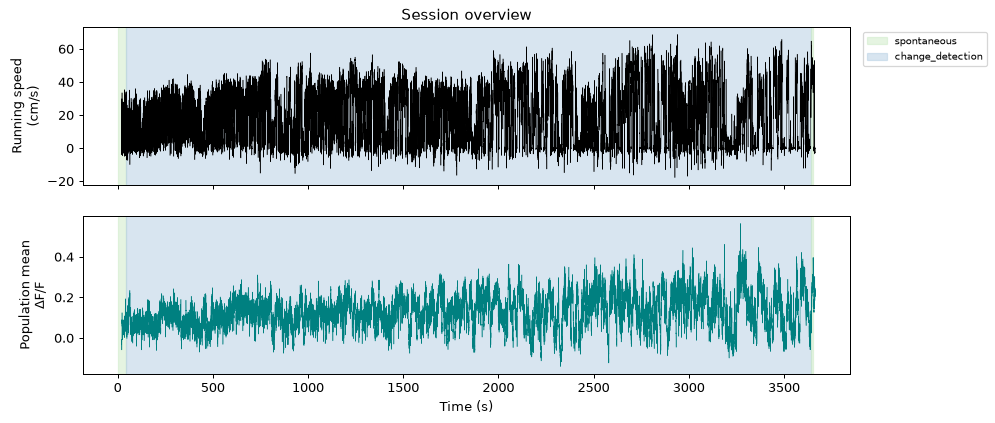

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

axes[0].plot(running_ts, running_speed, 'k', lw=0.4)
axes[0].set_ylabel('Running speed\n(cm/s)')
axes[0].set_title('Session overview')

axes[1].plot(timestamps, population, 'teal', lw=0.4)
axes[1].set_ylabel('Population mean\n' + r'$\Delta$F/F')
axes[1].set_xlabel('Time (s)')

for ax in axes:
    shade_epochs(ax)

# one legend entry per epoch label, even if a label appears more than once
handles, labels_ = axes[0].get_legend_handles_labels()
unique = dict(zip(labels_, handles))
axes[0].legend(unique.values(), unique.keys(),
               bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now test the *claim*, do not eyeball it.

The caption says population activity is higher during the stimulus block than during gray screen.
Compute the mean activity in each epoch. Before you look: what would make this comparison
unfair?

</div>

In [20]:
rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    if in_epoch.sum() < 10:
        continue
    rows.append({'epoch': label,
                 'duration_s': round(float(row.stop_time - row.start_time), 1),
                 'n_samples': int(in_epoch.sum()),
                 'mean_activity': round(float(population[in_epoch].mean()), 4)})

pd.DataFrame(rows)

,epoch,duration_s,n_samples,mean_activity
0,spontaneous,41.5,216,0.0551
1,change_detection,3602.4,38699,0.1290
2,spontaneous,9.3,99,0.2263


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Read the `duration_s` and `n_samples` columns before reading `mean_activity`.

In our session the epochs are wildly unequal: 41&nbsp;s of gray screen, then 3602&nbsp;s of task,
then 9&nbsp;s of gray screen. The final spontaneous period contributes **99 samples** &mdash; and it
has the *highest* mean activity of the three. So the caption's claim does not survive contact with
the epoch table: activity is higher during the task than during the first gray period, and higher
still during the last one.

Nothing in the session-overview figure hints at this. The shaded blocks look like three
comparable conditions.

Three things make the comparison unfair, and none are visible in the figure:

1. **Wildly unequal durations.** A mean from 99 samples and a mean from 38,699 samples are not
   equally precise. The short epoch is one long fluctuation away from any value you like.
2. **Time in session.** Epochs occur in a fixed order, so "epoch" is perfectly confounded with
   time. Calcium indicators bleach, animals get tired, and this session's population activity
   drifts upward throughout &mdash; visible in the overview plot if you look for it.
3. **Behavior.** If the animal runs more in one epoch, you may be measuring locomotion.

You cannot fix any of these with a better statistical test. They are properties of the experimental
design, which is why you check them before you run the analysis rather than after.

**The honest version of this claim** would compare equal-duration windows matched for time in
session and running state &mdash; and in this session there is not enough gray screen to do that.
Sometimes the right answer is that the figure's claim cannot be tested with this data.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Aggregating across trials &mdash; rasters and PSTHs</h1>

The session-overview plot shows everything at once, which means it shows very little. To see what
a neuron does in response to a stimulus you need to **align** activity to stimulus onsets and
average across repeats.

We will build this up one step at a time: one trial, then all trials, then the average.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Choose a condition and get its onset times</h3>

</div>

In [21]:
# How many times was each condition presented?
events[CONDITION_COLUMN].value_counts()

image_name
im069    763
im063    691
im065    633
im062    632
im077    561
im085    552
im066    525
im061    442
Name: count, dtype: int64

In [22]:
# EDIT: pick one condition to start with
condition = events[CONDITION_COLUMN].value_counts().index[0]

onsets = events.loc[events[CONDITION_COLUMN] == condition, ONSET_COLUMN].values

print(f'condition: {condition}')
print(f'presentations: {len(onsets)}')
print('first few onset times:', np.round(onsets[:5], 2))

condition: im069
presentations: 763
first few onset times: [ 97.86  98.61  99.36 100.11 100.86]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>One trial</h3>

Start with a single presentation. Find the frames in a window around the onset, and plot the
activity of one neuron.

</div>

In [23]:
# Which cell should we look at? Rank cells by how much their activity changes
# after stimulus onset, relative to their own variability.
pre, post = 0.5, 1.0

after = np.array([activity[(timestamps >= t0) & (timestamps < t0 + 0.5)].mean(axis=0)
                  for t0 in onsets[:200]])
before = np.array([activity[(timestamps >= t0 - 0.5) & (timestamps < t0)].mean(axis=0)
                   for t0 in onsets[:200]])

modulation = (after - before).mean(axis=0) / (after - before).std(axis=0)
ROI = int(np.argmax(modulation))

print(f'most stimulus-modulated cell: ROI {ROI}')
print(f'its modulation score: {modulation[ROI]:.3f}')
print(f'median across cells:  {np.median(modulation):.3f}')

most stimulus-modulated cell: ROI 25
its modulation score: 0.368
median across cells:  0.054


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

We picked the *most* stimulus-modulated cell, which is a choice you must disclose. A
figure of your best cell is a fine illustration and a terrible summary &mdash; the median cell in
this session is barely modulated at all.

Whenever you show an example neuron, say how you chose it. "ROI 0" is not neutral either; it is
just an undisclosed arbitrary choice rather than an undisclosed best-case one.

</div>

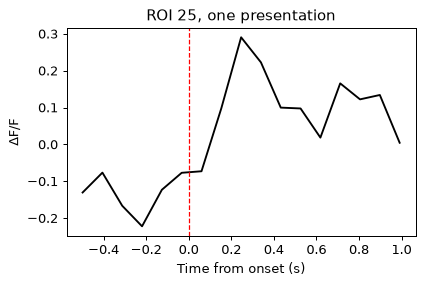

In [24]:
# Now look at one presentation for that cell

t0 = onsets[0]
in_window = (timestamps >= t0 - pre) & (timestamps < t0 + post)

plt.figure(figsize=(5, 3))
plt.plot(timestamps[in_window] - t0, activity[in_window, ROI], 'k')
plt.axvline(0, color='red', ls='--', lw=1)
plt.xlabel('Time from onset (s)')
plt.ylabel(r'$\Delta$F/F')
plt.title(f'ROI {ROI}, one presentation')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>All trials</h3>

One trial tells you nothing &mdash; it could be anything. Do the same for every presentation.

Rather than writing the loop again, we reuse `align_to_events` from this morning's tutorial.

</div>

In [25]:
def align_to_events(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : times for each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (windows, t) where t is the time axis in seconds
    relative to the event, and windows has one entry per event.
    """
    dt = np.median(np.diff(timestamps))
    n_pre, n_post = int(pre / dt), int(post / dt)

    windows = []
    for event_time in event_times:
        i = np.searchsorted(timestamps, event_time)

        # skip events too close to the start or end of the recording
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            windows.append(data[i - n_pre:i + n_post])

    t = np.arange(-n_pre, n_post) * dt
    return np.array(windows), t

In [26]:
windows, t = align_to_events(activity[:, ROI], timestamps, onsets, pre=pre, post=post)

print('windows shape (n_presentations, n_frames):', windows.shape)

windows shape (n_presentations, n_frames): (763, 15)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compare `windows.shape[0]` to `len(onsets)`. Are they the same?

Read the function again if they are not. Where did the missing trials go?

</div>

In [27]:
print('onsets:            ', len(onsets))
print('windows returned:  ', windows.shape[0])
print('trials dropped:    ', len(onsets) - windows.shape[0])

onsets:             763
windows returned:   763
trials dropped:     0


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

They may not match. `align_to_events` skips any event whose window would run off the start
or end of the recording &mdash; a sensible thing to do, since those windows would be the wrong
length.

But it does it **silently**. If you never compare the two numbers you will not know that some
trials were dropped, and every count you report downstream will be quietly wrong.

This is a small example of a large category: helper functions make reasonable decisions on your
behalf, and those decisions become invisible assumptions in your analysis. **Check the shape of
what comes back against what you expected to get.**

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The raster</h3>

A raster shows every trial at once: time on the x-axis, trial number on the y-axis, activity as
color. Nothing is averaged away, so it is the honest picture of trial-to-trial variability.

</div>

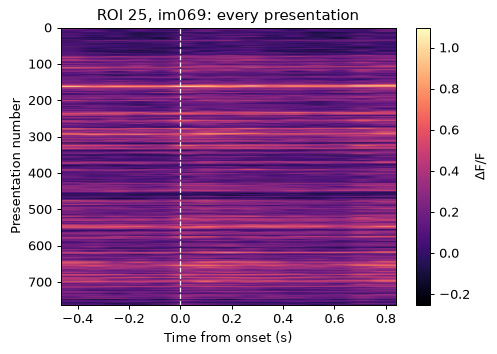

In [28]:
plt.figure(figsize=(6, 4))
plt.imshow(windows, aspect='auto', cmap='magma',
           extent=[t[0], t[-1], windows.shape[0], 0])
plt.colorbar(label=r'$\Delta$F/F')
plt.axvline(0, color='white', ls='--', lw=1)
plt.xlabel('Time from onset (s)')
plt.ylabel('Presentation number')
plt.title(f'ROI {ROI}, {condition}: every presentation')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The PSTH</h3>

The peri-stimulus time histogram is the average across trials, which is the bottom row of the
raster collapsed into a line. Always show a measure of spread with it &mdash; here the standard
error of the mean.

</div>

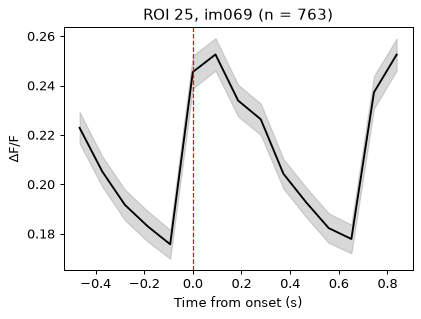

In [29]:
mean = windows.mean(axis=0)
sem = windows.std(axis=0) / np.sqrt(len(windows))

plt.figure(figsize=(5, 3.5))
plt.plot(t, mean, 'k')
plt.fill_between(t, mean - sem, mean + sem, color='gray', alpha=0.3)
plt.axvline(0, color='red', ls='--', lw=1)
plt.xlabel('Time from onset (s)')
plt.ylabel(r'$\Delta$F/F')
plt.title(f'ROI {ROI}, {condition} (n = {len(windows)})')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the raster and the PSTH side by side, with the single trials drawn
faintly behind the mean.

How much does an individual trial resemble the average?

</div>

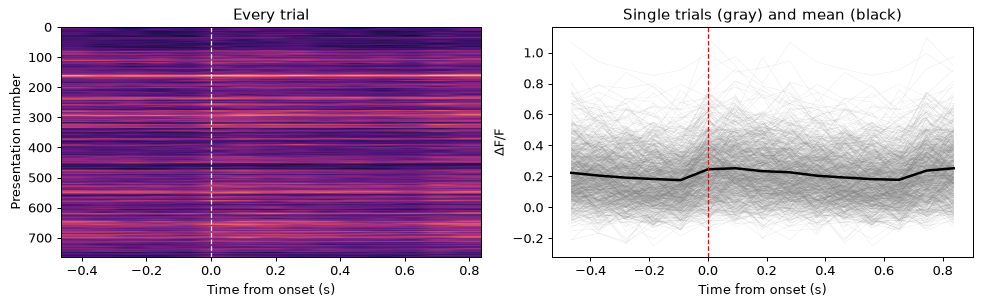

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].imshow(windows, aspect='auto', cmap='magma',
               extent=[t[0], t[-1], windows.shape[0], 0])
axes[0].axvline(0, color='white', ls='--', lw=1)
axes[0].set_xlabel('Time from onset (s)')
axes[0].set_ylabel('Presentation number')
axes[0].set_title('Every trial')

axes[1].plot(t, windows.T, color='gray', lw=0.3, alpha=0.2)
axes[1].plot(t, mean, 'k', lw=2)
axes[1].axvline(0, color='red', ls='--', lw=1)
axes[1].set_xlabel('Time from onset (s)')
axes[1].set_ylabel(r'$\Delta$F/F')
axes[1].set_title('Single trials (gray) and mean (black)')

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Almost no individual trial looks like the average. Even for the most modulated cell in
the session, the mean shows a modest bump after onset while individual trials are all over the
place, and many show nothing at all.

This is normal cortical data, not a quality problem. But it sets up the central question of the
rest of this notebook: **the average is a small signal extracted from large variability by
averaging.** How much you can trust it depends entirely on how many trials went into it.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Across neurons</h3>

So far, one neuron. Do the same for every neuron and stack the results.

</div>

In [31]:
responses = []
for roi in range(activity.shape[1]):
    windows_roi, t = align_to_events(activity[:, roi], timestamps, onsets, pre=pre, post=post)
    responses.append(windows_roi.mean(axis=0))

responses = np.array(responses)
print('responses shape (n_cells, n_timepoints):', responses.shape)

responses shape (n_cells, n_timepoints): (67, 15)


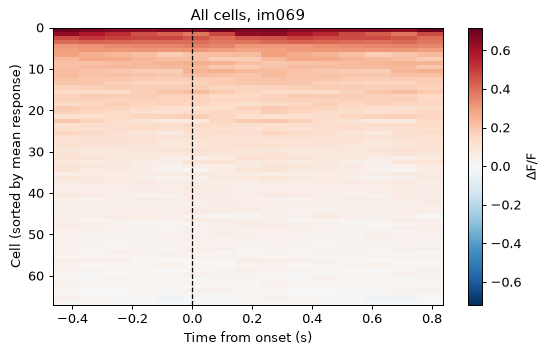

In [32]:
order = np.argsort(responses.mean(axis=1))[::-1]

plt.figure(figsize=(7, 4))
lim = np.abs(responses).max()
plt.imshow(responses[order], aspect='auto', cmap='RdBu_r',
           vmin=-lim, vmax=lim, extent=[t[0], t[-1], len(responses), 0])
plt.colorbar(label=r'$\Delta$F/F')
plt.axvline(0, color='k', ls='--', lw=1)
plt.xlabel('Time from onset (s)')
plt.ylabel('Cell (sorted by mean response)')
plt.title(f'All cells, {condition}')
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Neurons differ enormously. Sorting by mean response makes the range obvious: a minority
respond strongly, most barely at all, and some are suppressed.

Two kinds of variability are now on the table, and it is worth being precise about the difference:

- **Across trials** (the raster): the same neuron, the same stimulus, a different response each
  time.
- **Across neurons** (this heatmap): different neurons doing genuinely different things.

Signal and noise correlations, in Part 5, are exactly the tools for separating these two.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>A note on spike data</h3>

If your dataset has **spike times** instead of a continuous signal, `align_to_events` does not
apply directly &mdash; there is no regularly sampled array to slice.

The standard move is to **bin** the spikes: choose a bin width, count spikes per bin, and divide
by the bin width to get a rate. That gives you a regularly sampled array, and everything
downstream works the same way.

The bin width is a real analysis decision, exactly like the response window. Too wide and you blur
the response; too narrow and every bin is mostly zeros. Try a few and see how much your answer
moves.

</div>

In [33]:
# Template for spike data -- not used for our continuous example dataset.
#
# bin_width = 0.05                                     # seconds
# edges = np.arange(spike_times.min(), spike_times.max(), bin_width)
# counts, _ = np.histogram(spike_times, bins=edges)
# activity_binned = counts / bin_width                 # rate in Hz
# timestamps_binned = edges[:-1] + bin_width / 2

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: What a correlation coefficient actually computes</h1>

Before computing thousands of correlations, compute one by hand.

The Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words, and this is the version worth remembering:

1. **Center** each variable by subtracting its mean.
2. **Multiply** the centered values pointwise and add them up. This is large and positive when the
   two vary together, large and negative when they vary oppositely, near zero when unrelated.
3. **Normalize** by the spread of each variable, which forces the result between -1 and +1.

Two consequences that matter for everything below:

- $r$ says nothing about the *size* of a response, only whether two things move together. Doubling
  one variable does not change $r$.
- $r$ is computed over a set of paired observations. **How many observations you have determines
  how noisy $r$ is** &mdash; and the value itself gives you no clue how many there were.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Compute it by hand for two neurons</h3>

</div>

In [34]:
# Two neurons' responses across trials
x = windows_a = activity[:, 0]
y = activity[:, 1]

print('n observations:', len(x))

n observations: 39130


In [35]:
# Step 1: center
x_centered = x - x.mean()
y_centered = y - y.mean()

# Step 2: multiply and sum
numerator = np.sum(x_centered * y_centered)

# Step 3: normalize by the spread of each
denominator = np.sqrt(np.sum(x_centered ** 2)) * np.sqrt(np.sum(y_centered ** 2))

r_by_hand = numerator / denominator
print('r computed by hand:', round(r_by_hand, 6))

r computed by hand: -0.019638


In [36]:
# Check against numpy
r_numpy = np.corrcoef(x, y)[0, 1]

print('r from np.corrcoef:', round(r_numpy, 6))
print('difference:        ', abs(r_by_hand - r_numpy))

r from np.corrcoef: -0.019638
difference:         1.848465776277397e-09


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What does a given value of $r$ actually look like? Simulate pairs of
variables with known correlations and plot them.

Build your intuition here &mdash; people routinely overestimate how strong an $r$ of 0.3 looks.

</div>

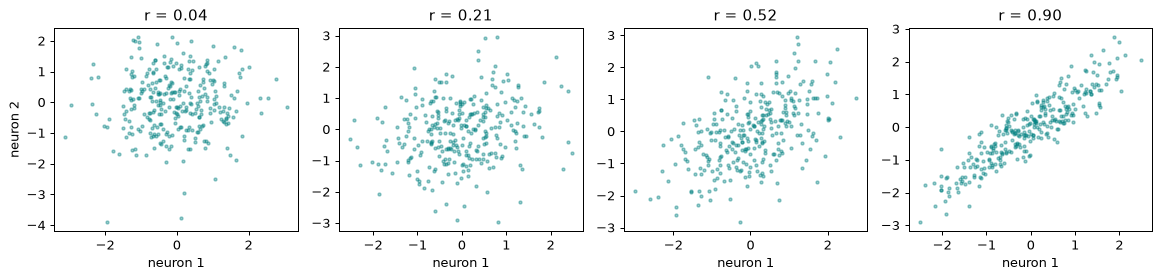

In [37]:
rng = np.random.default_rng(0)
n = 300

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))

for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    a = rng.normal(size=n)
    b = target_r * a + np.sqrt(1 - target_r ** 2) * rng.normal(size=n)
    ax.scatter(a, b, s=6, alpha=0.4, color='teal')
    ax.set_title(f'r = {np.corrcoef(a, b)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')

axes[0].set_ylabel('neuron 2')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

An $r$ of 0.2 looks like a formless blob. An $r$ of 0.5 is a cloud you would not confidently
call a relationship by eye.

Remember these pictures. Mean pairwise correlations in cortex are typically in the 0.01&ndash;0.1
range &mdash; far weaker than the leftmost panel here. Such correlations are real and consequential
at the population level, but no single pair of neurons will look impressive.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>All pairs at once</h3>

`np.corrcoef` on a matrix correlates its **rows**. Our activity matrix is
`(timepoints, cells)`, so we transpose to correlate cells rather than timepoints.

Getting this backwards is a classic bug that produces a plausible-looking matrix of entirely the
wrong thing. Check the output shape against the number of cells.

</div>

In [38]:
C = np.corrcoef(activity.T)      # transpose: we want cells, not timepoints

print('activity: ', activity.shape, '(timepoints, cells)')
print('C:        ', C.shape, '-> should be (n_cells, n_cells)')

activity:  (39130, 67) (timepoints, cells)
C:         (67, 67) -> should be (n_cells, n_cells)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** The correlation matrix contains every pair twice, plus a diagonal of ones.
For distributions and averages you want each pair once.

Use `np.triu_indices(n, k=1)` to take the upper triangle, excluding the diagonal.

</div>

In [39]:
pairs = np.triu_indices(C.shape[0], k=1)
values = C[pairs]

n_cells = C.shape[0]
print(f'{n_cells} cells -> {len(values)} unique pairs  (n*(n-1)/2 = {n_cells * (n_cells - 1) // 2})')
print(f'mean pairwise correlation: {np.nanmean(values):.4f}')

67 cells -> 2211 unique pairs  (n*(n-1)/2 = 2211)
mean pairwise correlation: 0.1233


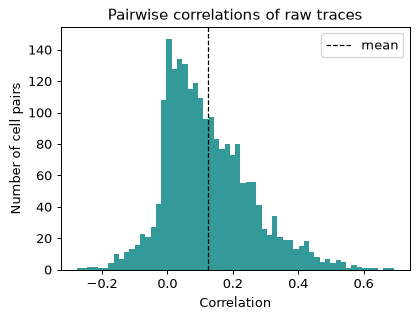

In [40]:
plt.figure(figsize=(5, 3.5))
plt.hist(values, bins=60, color='teal', alpha=0.8)
plt.axvline(np.nanmean(values), color='k', ls='--', lw=1, label='mean')
plt.xlabel('Correlation')
plt.ylabel('Number of cell pairs')
plt.title('Pairwise correlations of raw traces')
plt.legend()
plt.show()

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 5: Signal and noise correlations</h1>

Two neurons recorded together are correlated for two different reasons, and telling them apart is
one of the most useful things you can do with population data.

- **Signal correlation.** Do they *like the same stimuli*? Take each neuron's average response to
  each condition &mdash; its tuning curve &mdash; and correlate the two neurons' tuning curves.
- **Noise correlation.** When the *same* stimulus is repeated, do they fluctuate together around
  their own averages? Subtract each condition's mean to get residuals, and correlate those.

Both come from the same data. They differ only in what you average over. That is worth restating:

| | what is correlated | one observation is |
| --- | --- | --- |
| signal | condition means | one condition |
| noise | within-condition residuals | one trial |

Keep that last column in mind. It turns out to matter more than anything else in this notebook.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: choose which events to use</h3>

Not every event in your table is comparable to every other. Before computing anything, decide
which subset is a fair comparison, and write down why.

</div>

In [41]:
# EDIT: restrict to comparable events for your dataset.
subset = events.copy()

# In this change-detection task, "change" presentations are behaviorally special
# and "omitted" presentations are not stimuli at all. We keep only the repeats.
if 'is_change' in subset.columns:
    subset = subset[subset['is_change'] != 1]
if 'omitted' in subset.columns:
    subset = subset[subset['omitted'] != 1]

onsets_all = subset[ONSET_COLUMN].values
labels = subset[CONDITION_COLUMN].values

print(f'{len(events)} events -> {len(subset)} after filtering')
print(pd.Series(labels).value_counts().to_string())

4799 events -> 4574 after filtering
im069    734
im063    663
im065    605
im062    604
im077    533
im085    524
im066    497
im061    414


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

We use the repeated presentations, not the changes. Both show the same images, so either
could define conditions &mdash; but changes are followed by licking and reward, which would mix
behavior-driven variability into what we are calling "noise".

The cost: repeats are the *unattended* stimuli, so this is tuning during relatively passive
viewing. Using changes instead would give roughly 28 trials per image instead of several hundred.

**There is no universally right answer here.** What matters is that you made the choice
deliberately and can state it.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: one number per trial per neuron</h3>

For the correlations we need a single response value per trial per neuron: a
`(n_trials, n_cells)` matrix.

Two decisions go into that one number:

- **The response window.** How long after onset to average over.
- **Whether to subtract a baseline.** A cell's dF/F sits at some level even with no stimulus, and
  that level drifts over a session. Subtracting the activity in a short window *before* each onset
  measures the change the stimulus caused, rather than the level the cell happened to be at.

We will compute it both ways and compare, because this decision turns out to matter a great
deal.

</div>

In [42]:
RESPONSE_WINDOW = (0.0, 0.5)       # seconds after onset
BASELINE_WINDOW = (-0.25, 0.0)     # seconds before onset

R_no_baseline, R = [], []

for roi in range(activity.shape[1]):
    windows_roi, t_roi = align_to_events(activity[:, roi], timestamps, onsets_all,
                                         pre=-BASELINE_WINDOW[0], post=RESPONSE_WINDOW[1])
    is_baseline = t_roi < 0
    is_response = t_roi >= 0

    response = windows_roi[:, is_response].mean(axis=1)
    baseline = windows_roi[:, is_baseline].mean(axis=1)

    R_no_baseline.append(response)
    R.append(response - baseline)

R_no_baseline = np.array(R_no_baseline).T     # (n_trials, n_cells)
R = np.array(R).T

print('R shape (n_trials, n_cells):', R.shape)

R shape (n_trials, n_cells): (4574, 67)


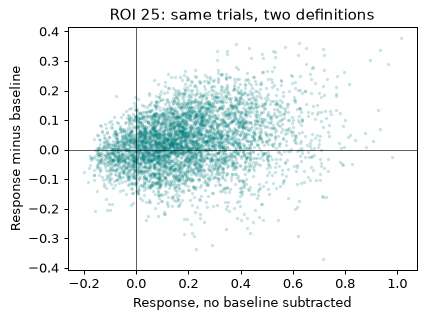

In [43]:
# What did subtracting the baseline change?
plt.figure(figsize=(5, 3.5))
plt.scatter(R_no_baseline[:, ROI], R[:, ROI], s=3, alpha=0.15, color='teal')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.xlabel('Response, no baseline subtracted')
plt.ylabel('Response minus baseline')
plt.title(f'ROI {ROI}: same trials, two definitions')
plt.show()

In [44]:
# align_to_events may have dropped trials -- keep labels in register with R
labels_used = labels[:R.shape[0]]

print('trials in R:      ', R.shape[0])
print('labels kept:      ', len(labels_used))
print('conditions:       ', len(np.unique(labels_used)))

trials in R:       4574
labels kept:       4574
conditions:        8


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: tuning curves &mdash; look before correlating</h3>

The tuning curve is the per-condition average of each neuron. Plot some before correlating
anything.

</div>

In [45]:
conditions = np.unique(labels_used)

tuning = np.vstack([R[labels_used == c].mean(axis=0) for c in conditions])

print('tuning shape (n_conditions, n_cells):', tuning.shape)

tuning shape (n_conditions, n_cells): (8, 67)


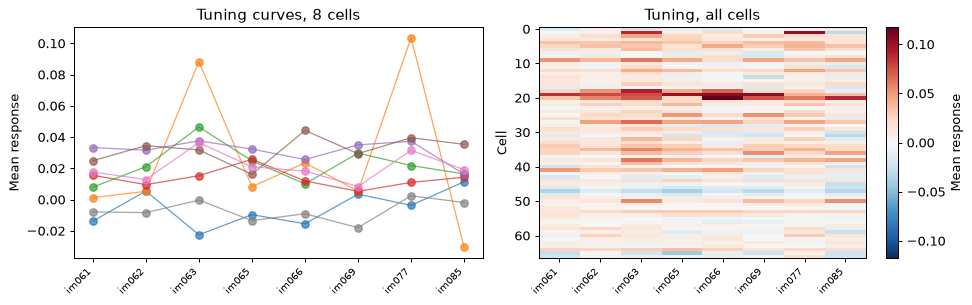

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for roi in range(min(8, tuning.shape[1])):
    axes[0].plot(range(len(conditions)), tuning[:, roi], marker='o', lw=1, alpha=0.7)
axes[0].set_xticks(range(len(conditions)))
axes[0].set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean response')
axes[0].set_title('Tuning curves, 8 cells')

lim = np.abs(tuning).max()
im = axes[1].imshow(tuning.T, aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[1].set_xticks(range(len(conditions)))
axes[1].set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Cell')
axes[1].set_title('Tuning, all cells')
plt.colorbar(im, ax=axes[1], label='Mean response')

plt.tight_layout()
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** How many numbers make up one neuron's tuning curve?

That is the number of observations that will go into each signal correlation. Write it down.

</div>

In [47]:
print('numbers per tuning curve:', tuning.shape[0])
print('(this is how many paired observations each signal correlation is computed from)')

numbers per tuning curve: 8
(this is how many paired observations each signal correlation is computed from)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: residuals &mdash; look before correlating</h3>

For noise correlations we subtract **each condition's own mean**, not the grand mean. If you
subtract the grand mean, the differences between conditions stay in the residuals and your "noise"
correlation is partly a signal correlation.

</div>

In [48]:
residuals = R.copy().astype(float)

for c in conditions:
    mask = labels_used == c
    residuals[mask] -= R[mask].mean(axis=0)      # each condition's OWN mean

print('residuals shape:', residuals.shape)
print('mean of residuals (should be ~0):', round(float(residuals.mean()), 10))

residuals shape: (4574, 67)
mean of residuals (should be ~0): -2e-10


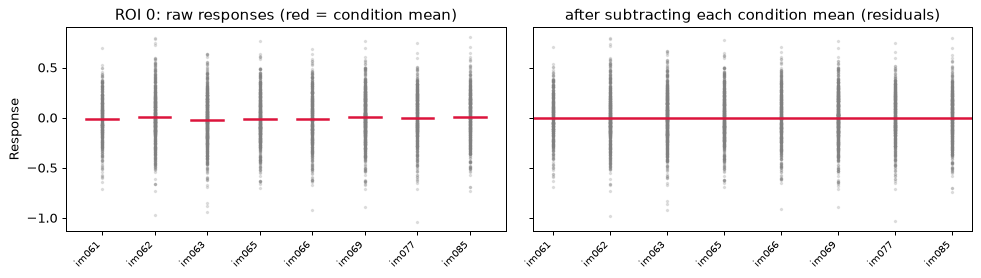

In [49]:
roi = 0

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)

for i, c in enumerate(conditions):
    axes[0].scatter(np.full((labels_used == c).sum(), i), R[labels_used == c, roi],
                    s=3, alpha=0.2, color='gray')
    axes[0].plot([i - 0.3, i + 0.3], [tuning[i, roi]] * 2, color='crimson', lw=2)
axes[0].set_title(f'ROI {roi}: raw responses (red = condition mean)')
axes[0].set_ylabel('Response')

for i, c in enumerate(conditions):
    axes[1].scatter(np.full((labels_used == c).sum(), i), residuals[labels_used == c, roi],
                    s=3, alpha=0.2, color='gray')
axes[1].axhline(0, color='crimson', lw=2)
axes[1].set_title('after subtracting each condition mean (residuals)')

for ax in axes:
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: correlate</h3>

Both are now `np.corrcoef` on a transposed matrix, exactly as in Part 4.

</div>

In [50]:
C_signal = np.corrcoef(tuning.T)         # (n_conditions, n_cells) -> correlate cells
C_noise = np.corrcoef(residuals.T)       # (n_trials, n_cells)     -> correlate cells

pairs = np.triu_indices(C_signal.shape[0], k=1)
signal_values = C_signal[pairs]
noise_values = C_noise[pairs]

print(f'signal correlation: mean {np.nanmean(signal_values):+.4f}   '
      f'(from {tuning.shape[0]} observations per pair)')
print(f'noise  correlation: mean {np.nanmean(noise_values):+.4f}   '
      f'(from {residuals.shape[0]} observations per pair)')

signal correlation: mean +0.1168   (from 8 observations per pair)
noise  correlation: mean +0.0356   (from 4574 observations per pair)


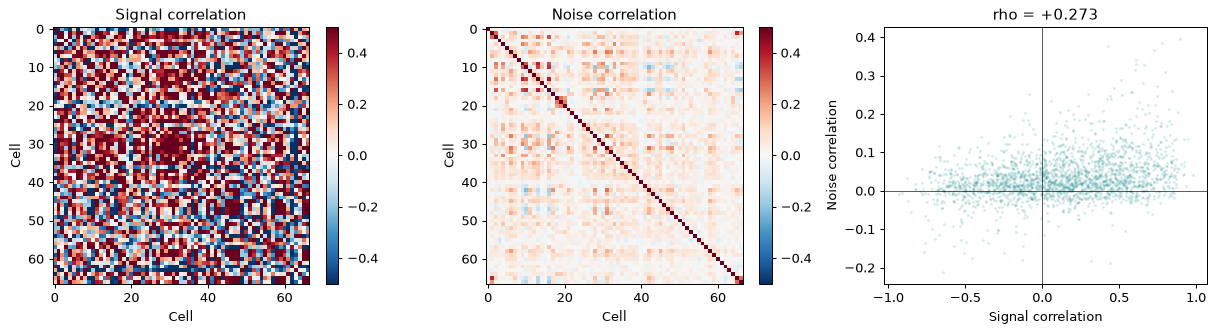

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for ax, C, label in [(axes[0], C_signal, 'Signal correlation'),
                     (axes[1], C_noise, 'Noise correlation')]:
    im = ax.imshow(C, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    ax.set_xlabel('Cell')
    ax.set_ylabel('Cell')
    ax.set_title(label)
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[2].scatter(signal_values, noise_values, s=2, alpha=0.1, color='teal')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].axvline(0, color='k', lw=0.5)
axes[2].set_xlabel('Signal correlation')
axes[2].set_ylabel('Noise correlation')

rho, p_value = stats.spearmanr(signal_values, noise_values, nan_policy='omit')
axes[2].set_title(f'rho = {rho:+.3f}')

plt.tight_layout()
plt.show()

In [52]:
# The same correlations WITHOUT baseline subtraction
Cs_nb = np.corrcoef(np.vstack([R_no_baseline[labels_used == c].mean(axis=0)
                               for c in conditions]).T)
resid_nb = R_no_baseline.astype(float).copy()
for c in conditions:
    m = labels_used == c
    resid_nb[m] -= R_no_baseline[m].mean(axis=0)
Cn_nb = np.corrcoef(resid_nb.T)

print('                       signal    noise')
print(f'baseline subtracted:  {np.nanmean(signal_values):+.4f}  {np.nanmean(noise_values):+.4f}')
print(f'no baseline:          {np.nanmean(Cs_nb[pairs]):+.4f}  {np.nanmean(Cn_nb[pairs]):+.4f}')

                       signal    noise
baseline subtracted:  +0.1168  +0.0356
no baseline:          +0.1052  +0.2041


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Skipping the baseline subtraction roughly **quadruples** the mean noise correlation.

The reason is worth understanding, because it generalizes. Without a baseline, each trial's
"response" includes wherever that cell's dF/F happened to be sitting. Those levels drift slowly and
they drift *together* across the population &mdash; from bleaching, from arousal, from running. So
you end up measuring shared slow drift and calling it noise correlation.

Neither number is wrong; they measure different things. But only one of them is what people mean
by "noise correlation", and the figure looks identical either way. We continue with the
baseline-subtracted version.

</div>

<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Signal and noise correlations are positively related. That is the classic result: neurons
that like the same stimuli also share their trial-to-trial fluctuations. It has been found in
essentially every cortical area, and it matters for coding, because shared noise aligned with the
signal does not average away as you add neurons.

Now look at the two matrices side by side &mdash; not the numbers, the *texture*. The noise matrix
has visible structure: blocks, stripes, a mostly-positive background. The signal matrix is
salt-and-pepper, spanning the full range with little organization. That is what a matrix of
**badly estimated** correlations looks like.

Both were computed with the same function, from the same data, and both look publication-ready.
Part 6 shows how to tell them apart.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 6: Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. Three checks, in order of how often
they catch something:

1. Would you get the same answer with **half the data**?
2. How much does the answer depend on the **response window** you picked?
3. Does an analysis that *should* return nothing actually return nothing?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Check 1: split-half reliability</h3>

Split the trials in half at random, compute the correlation matrix on each half separately, and
correlate the two halves' answers. If the result is real and well estimated, the halves agree.

Split **within each condition**, so both halves see every condition.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Before running it: which do you expect to be more reliable, signal or noise
correlations? Look back at the observation counts you printed in Part 5.

</div>

In [53]:
rng = np.random.default_rng(0)

def split_half_once(R, labels, seed_rng):
    """Split trials within condition, return correlation matrices for each half."""
    half_a, half_b = [], []
    for c in np.unique(labels):
        idx = seed_rng.permutation(np.flatnonzero(labels == c))
        h = len(idx) // 2
        half_a.append(idx[:h])
        half_b.append(idx[h:2 * h])
    return np.concatenate(half_a), np.concatenate(half_b)


def correlations_from(R_sub, labels_sub):
    """Signal and noise correlation matrices from a subset of trials."""
    conds = np.unique(labels_sub)
    tuning_sub = np.vstack([R_sub[labels_sub == c].mean(axis=0) for c in conds])
    resid_sub = R_sub.astype(float).copy()
    for c in conds:
        m = labels_sub == c
        resid_sub[m] -= R_sub[m].mean(axis=0)
    return np.corrcoef(tuning_sub.T), np.corrcoef(resid_sub.T)

In [54]:
signal_reliability, noise_reliability = [], []

for _ in range(10):
    a, b = split_half_once(R, labels_used, rng)
    Cs_a, Cn_a = correlations_from(R[a], labels_used[a])
    Cs_b, Cn_b = correlations_from(R[b], labels_used[b])

    signal_reliability.append(stats.spearmanr(Cs_a[pairs], Cs_b[pairs], nan_policy='omit').statistic)
    noise_reliability.append(stats.spearmanr(Cn_a[pairs], Cn_b[pairs], nan_policy='omit').statistic)

signal_reliability = np.array(signal_reliability)
noise_reliability = np.array(noise_reliability)

print('split-half reliability (agreement between two independent halves)')
print(f'  signal: {signal_reliability.mean():.3f} +/- {signal_reliability.std():.3f}')
print(f'  noise:  {noise_reliability.mean():.3f} +/- {noise_reliability.std():.3f}')

split-half reliability (agreement between two independent halves)
  signal: 0.403 +/- 0.016
  noise:  0.777 +/- 0.008


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

**This is the most important result in the notebook.**

Noise correlations reproduce almost perfectly across independent halves. Signal correlations
reproduce only moderately &mdash; halve the data and you recover about half the structure.

The reason is the observation counts you wrote down in Part 5. Each noise correlation is computed
from thousands of trials. Each signal correlation is computed from **one number per condition**
&mdash; and correlating two short vectors is noisy no matter how many trials went into each entry.

Look back at the heatmaps in Part 5. They are equally smooth and equally colorful. **Nothing in
that figure tells you one is far more trustworthy than the other.** You only know because you
split the data and checked.

The general lesson: the reliability of a correlation is set by the number of *observations being
correlated*, not the number of trials you collected. Count them.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Check 2: does the answer depend on the window?</h3>

We picked a response window in Part 5 without much justification. See how much it mattered.

</div>

In [55]:
rows = []
for window in [(0.0, 0.25), (0.0, 0.5), (0.0, 0.75), (-0.5, 0.0)]:
    R_w = []
    for roi in range(activity.shape[1]):
        w, _ = align_to_events(activity[:, roi], timestamps, onsets_all,
                               pre=max(0.0, -window[0]), post=max(0.0, window[1]))
        R_w.append(w.mean(axis=1))
    R_w = np.array(R_w).T
    lab_w = labels[:R_w.shape[0]]

    Cs_w, Cn_w = correlations_from(R_w, lab_w)
    rows.append({'window': str(window),
                 'signal_mean': round(float(np.nanmean(Cs_w[pairs])), 4),
                 'noise_mean': round(float(np.nanmean(Cn_w[pairs])), 4)})

pd.DataFrame(rows)

,window,signal_mean,noise_mean
0,"(0.0, 0.25)",0.0816,0.1555
1,"(0.0, 0.5)",0.1052,0.2041
2,"(0.0, 0.75)",0.1030,0.2224
3,"(-0.5, 0.0)",0.1070,0.2008


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Move the window and the numbers move. Widening from 0.25&nbsp;s to 0.75&nbsp;s substantially
raises the mean noise correlation.

The last row is the one to think about. That window sits **entirely before the stimulus**, where
by construction there can be no stimulus response &mdash; and it produces the *largest* noise
correlation in the table. Nothing about that number looks broken.

It is not a bug: it is measuring slow shared drift in the population, which is real. But it is not
what anyone means by "noise correlation during stimulus presentation".

Two lessons. **Always report your window** &mdash; a correlation without one is uninterpretable.
And a check that returns a large, stable, plausible number is not thereby validated. Run the
version that *should* give nothing, and see what happens.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Check 3: what if you get the condition-mean subtraction wrong?</h3>

In Part 5 we saw what skipping the *baseline* does. This is a different mistake: computing
"noise" correlations without removing each **condition's** mean.

</div>

In [56]:
C_noise_wrong = np.corrcoef(R.T)      # residuals never taken

print(f'noise correlation, means removed (correct): {np.nanmean(C_noise[pairs]):+.4f}')
print(f'noise correlation, means NOT removed:       {np.nanmean(C_noise_wrong[pairs]):+.4f}')

variance_from_condition = tuning.var(axis=0).mean() / R.var(axis=0).mean()
print(f'\nfraction of response variance explained by condition: {variance_from_condition:.4f}')

noise correlation, means removed (correct): +0.0356
noise correlation, means NOT removed:       +0.0364

fraction of response variance explained by condition: 0.0085


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

In this dataset the mistake barely matters &mdash; the two numbers differ in about the
fourth decimal place. That is worth knowing, and it is **not** a reason to skip the step.

The last line explains why: condition identity explains only a percent or two of the response
variance here, so there is almost no signal available to leak into the residuals.

Now imagine strongly tuned neurons &mdash; drifting gratings in V1, where a cell might fire ten
times more to its preferred direction than its null. There, condition identity explains a large
share of the variance, and skipping the subtraction would inflate the noise correlation badly.

**The severity of this bug is a property of the dataset, not of the code.** The same error is
negligible in one dataset and disqualifying in another, and you cannot know which case you are in
without measuring the variance decomposition &mdash; one line that almost nobody runs.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What three things would someone need from you to reproduce your correlation
numbers exactly?

</div>

*Answer:*

1. **Which events, and which condition column** &mdash; including everything you excluded (changes,
   omissions, disengaged trials) and why.
2. **The response window and baseline**, with signs, and whether a baseline was subtracted at all.
3. **The number of conditions and the number of trials per condition**, since these determine the
   reliability and cannot be recovered from the correlation values.

A good habit: report split-half reliability alongside any correlation matrix you publish. It costs
a few lines and tells the reader how much of your matrix is signal.

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 7: Which questions can this dataset answer?</h1>

You have now run this analysis on one dataset. The last skill is knowing when *not* to.

Signal correlations need a **condition that repeats**. No repeats, no tuning curve, no signal
correlation. That is a property of the experiment, and you can check it before writing any
analysis code.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Inventory the candidate condition columns in your event table: how many
distinct values, how many repeats of each, how balanced.

Then state a verdict: can you compute signal correlations with this dataset?

</div>

In [57]:
rows = []
for column in events.columns:
    values = events[column].dropna()
    if len(values) == 0:
        continue
    try:
        n_conditions = values.nunique()
    except TypeError:
        continue                       # unhashable column, e.g. arrays
    if not (2 <= n_conditions <= 60):
        continue
    counts = values.value_counts()
    rows.append({'column': column,
                 'n_conditions': int(n_conditions),
                 'min_reps': int(counts.min()),
                 'max_reps': int(counts.max()),
                 'balance': round(counts.min() / counts.max(), 2)})

condition_inventory = pd.DataFrame(rows).sort_values('n_conditions', ascending=False)
condition_inventory

,column,n_conditions,min_reps,max_reps,balance
0,HED,16,28,734,0.04
1,image_name,8,442,763,0.58
2,is_change,2,225,4574,0.05


In [58]:
MIN_CONDITIONS, MIN_REPS = 3, 8

usable = condition_inventory[(condition_inventory.n_conditions >= MIN_CONDITIONS)
                             & (condition_inventory.min_reps >= MIN_REPS)]

if len(usable):
    print('Signal correlations ARE computable. Candidate columns:')
    print(usable.to_string(index=False))
else:
    print(f'No column has >= {MIN_CONDITIONS} conditions with >= {MIN_REPS} repeats each.')
    print('Signal correlations are NOT computable with this dataset.')
    print('Noise correlations may still be, if there is repeated structure to work with.')

Signal correlations ARE computable. Candidate columns:
    column  n_conditions  min_reps  max_reps  balance
       HED            16        28       734     0.04
image_name             8       442       763     0.58


<div style="border-left: 3px solid #7B9E3F; padding: 1px; padding-left: 10px; background: #FBFDF7; ">

<b>SOLUTION.</b> <i>Worked here on one example dataset. Your dataset will give different numbers &mdash; the reasoning is what transfers.</i>

Our example passes, with 8 images at several hundred presentations each.

Note that this check is agnostic about *meaning*: it reports any column with the right shape. An
ID column with 20 values and 30 repeats each would pass and be nonsense. **The code tells you
whether the analysis is possible; only you can tell whether it is sensible.**

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>When the answer is "you cannot do this"</h3>

Some datasets have no repeated stimulus conditions at all. A brain&ndash;computer-interface
experiment, for example, may consist of spontaneous periods, photostimulation of individual
neurons, and trials where the animal controls a lickport with its own neural activity. Nothing
repeats the way a grating or an image does.

Run the inventory and the verdict comes back negative. **That is a result, not a failure.** Do not
invent a condition variable to force the analysis.

What such a dataset *can* support:

- **Noise correlations**, which need no conditions at all &mdash; compute them within each epoch
  and compare across epochs, being careful about the confounds from Part 2.
- **Direct connectivity**, if single neurons were photostimulated. Measuring how every other
  neuron responds to stimulating one is far stronger evidence of coupling than any correlation.

When a dataset cannot answer your question, ask what question it *is* unusually good for. Often
that is the better question.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For your dataset, fill in this table in your README.

| question | can this dataset answer it? | what would be needed |
| --- | --- | --- |
| Do similarly tuned neurons share noise? | | many repeats of several conditions |
| Does coupling change with behavioral state? | | behavior recorded alongside neural data |
| Are two neurons connected? | | perturbation, not just correlation |
| Does cell type predict function? | | cell type labels |

Then add one question of your own that this dataset is *unusually well suited* to answer.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Inventory before analysis.** Modality, sampling rate, cell count, conditions, repeats,
   behavior, session structure &mdash; and what is missing.
2. **Check that the dataset supports the question** before writing the analysis. Sometimes the
   answer is no.
3. **Look at the data before summarizing it.** Single trials before averages; tuning curves before
   correlations.
4. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
5. **Try to break your own result.** Split-half reliability, parameter sensitivity, and an
   analysis that should return nothing.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| A helper function silently drops data | compare output shape to input |
| The answer depends on an arbitrary parameter | recompute across a range |
| A check returns a big, plausible number | run the version that should return nothing |
| A bug's severity depends on the dataset | measure the variance decomposition |
| Data looks absent but is stored elsewhere | look in every container before concluding |
| Epoch comparisons are confounded with time and state | check durations, order, and behavior |

<h3>Why this matters now</h3>

You can generate an analysis faster than you can validate one. That asymmetry is new and it is
growing. The only defense is to know your data well enough that a wrong answer looks wrong to
**you** &mdash; because it will not look wrong to the code, and it will not look wrong on the
plot.

</div>